In [1]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np

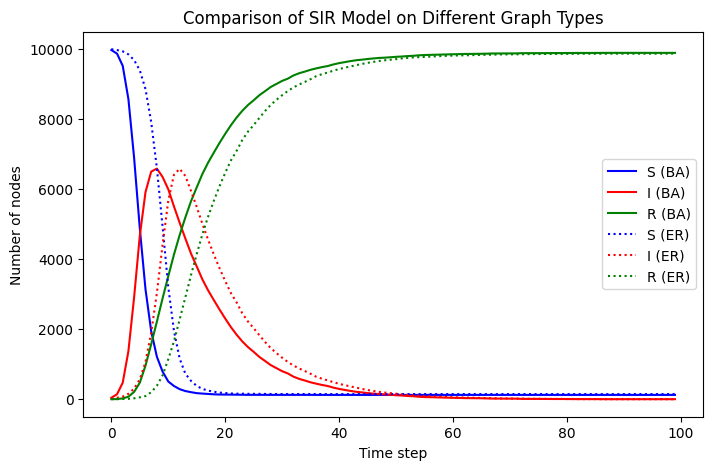

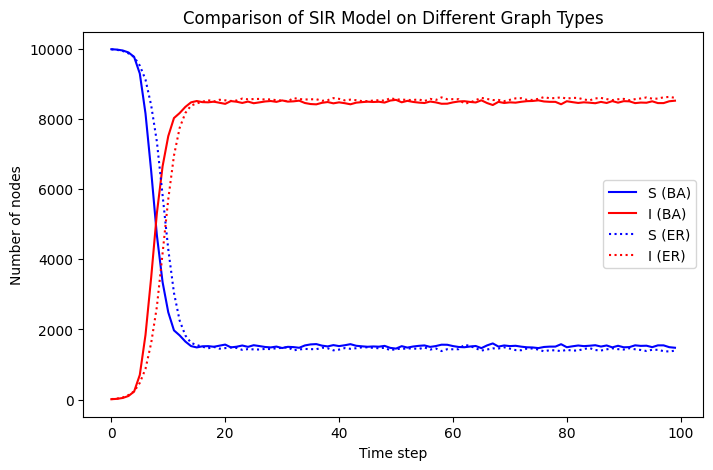

In [2]:
def simulate_epidemic(G, model="SIR", steps=60, beta=0.2, gamma=0.1, initial_infected=10):

    states = {node: "S" for node in G.nodes()}
    infected = random.sample(list(G.nodes()), initial_infected)

    for node in infected:
        states[node] = "I"

    history_S = []
    history_I = []
    history_R = []

    for _ in range(steps):

        new_states = states.copy()

        for node in G.nodes():

            if states[node] == "I":

                for neighbor in G.neighbors(node):
                    if states[neighbor] == "S" and random.random() < beta:
                        new_states[neighbor] = "I"

                if random.random() < gamma:
                    if model == "SIS":
                        new_states[node] = "S"
                    elif model == "SIR":
                        new_states[node] = "R"

        states = new_states

        S = list(states.values()).count("S")
        I = list(states.values()).count("I")
        R = list(states.values()).count("R")

        history_S.append(S)
        history_I.append(I)
        history_R.append(R)

    return history_S, history_I, history_R


# Parameters
N = 10000
steps = 100

# Graphs
G_barabasi = nx.barabasi_albert_graph(N, 3) #AVG 6 degree nodes
G_erdos = nx.erdos_renyi_graph(N, 6/N) #AVG 6 degree nodes


# Simulations
S_sis_ba, I_sis_ba, R_sis_ba = simulate_epidemic(G_barabasi, "SIS", steps)
S_sis_er, I_sis_er, R_sis_er = simulate_epidemic(G_erdos, "SIS", steps)
S_sir_ba, I_sir_ba, R_sir_ba = simulate_epidemic(G_barabasi, "SIR", steps)
S_sir_er, I_sir_er, R_sir_er = simulate_epidemic(G_erdos, "SIR", steps)

# Colors correspond to state
color_S = "blue"
color_I = "red"
color_R = "green"

# Plot
plt.figure(figsize=(8,5))
# SIR Barabasi (solid)
plt.plot(S_sir_ba, color=color_S, linestyle="-", label="S (BA)")
plt.plot(I_sir_ba, color=color_I, linestyle="-", label="I (BA)")
plt.plot(R_sir_ba, color=color_R, linestyle="-", label="R (BA)")
# SIR Erdos (dotted)
plt.plot(S_sir_er, color=color_S, linestyle=":", label="S (ER)")
plt.plot(I_sir_er, color=color_I, linestyle=":", label="I (ER)")
plt.plot(R_sir_er, color=color_R, linestyle=":", label="R (ER)")
plt.xlabel("Time step")
plt.ylabel("Number of nodes")
plt.title("Comparison of SIR Model on Different Graph Types")
plt.legend()
plt.show()

# Plot
plt.figure(figsize=(8,5))
# SIR Barabasi (solid)
plt.plot(S_sis_ba, color=color_S, linestyle="-", label="S (BA)")
plt.plot(I_sis_ba, color=color_I, linestyle="-", label="I (BA)")
# SIR Erdos (dotted)
plt.plot(S_sis_er, color=color_S, linestyle=":", label="S (ER)")
plt.plot(I_sis_er, color=color_I, linestyle=":", label="I (ER)")
plt.xlabel("Time step")
plt.ylabel("Number of nodes")
plt.title("Comparison of SIR Model on Different Graph Types")
plt.legend()
plt.show()


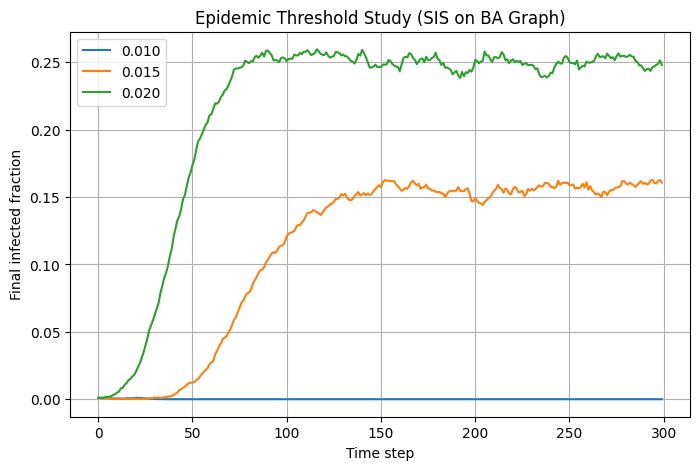

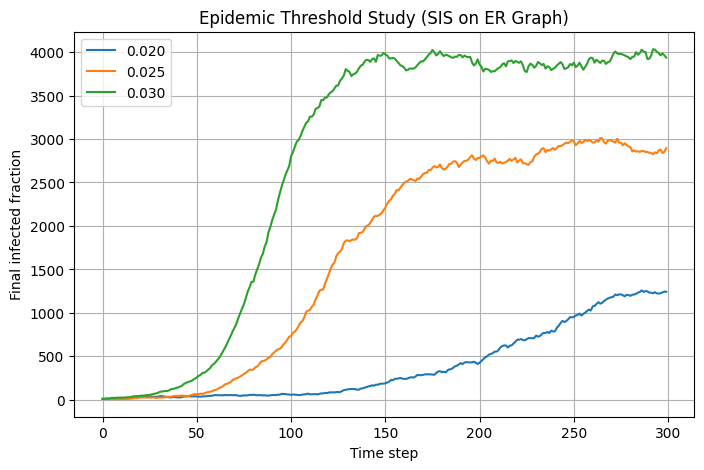

In [3]:
beta_values = [0.01, 0.015, 0.02]
steps = 300

plt.figure(figsize=(8,5))
for beta in beta_values:
    S_sis_ba, I_sis_ba, R_sis_ba = simulate_epidemic(G_barabasi, "SIS", steps, beta=beta)
    plt.plot(np.array(I_sis_ba)/N, label=f"{beta:.3f}")

plt.xlabel("Time step")
plt.ylabel("Final infected fraction")
plt.title("Epidemic Threshold Study (SIS on BA Graph)")
plt.legend()
plt.grid(True)
plt.show()

beta_values = [0.02,0.025,0.03]

plt.figure(figsize=(8,5))
for beta in beta_values:
    S_sis_ba, I_sis_ba, R_sis_ba = simulate_epidemic(G_erdos, "SIS", steps, beta=beta)
    plt.plot(I_sis_ba, label=f"{beta:.3f}")

plt.xlabel("Time step")
plt.ylabel("Final infected fraction")
plt.title("Epidemic Threshold Study (SIS on ER Graph)")
plt.legend()
plt.grid(True)
plt.show()